<a href="https://colab.research.google.com/github/anarghasunil2014-eng/My-projects-in-RNN/blob/main/Prediction_of_temparature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(80, 3)
(80, 1)
Epoch    0 Loss = 0.486303
Epoch  100 Loss = 0.045484
Epoch  200 Loss = 0.045447
Epoch  300 Loss = 0.045423
Epoch  400 Loss = 0.045404
Epoch  500 Loss = 0.045390
Epoch  600 Loss = 0.045378
Epoch  700 Loss = 0.045367
Epoch  800 Loss = 0.045357
Epoch  900 Loss = 0.045347
MSE : 2.6479


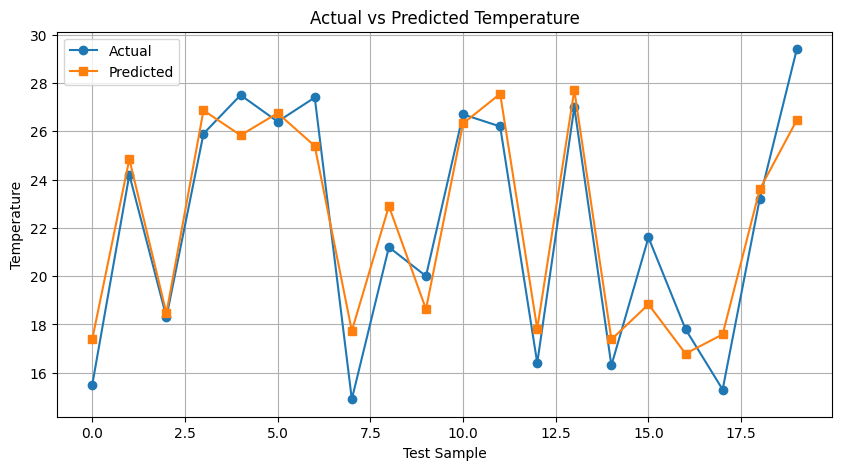

In [7]:
# Vanilla RNN Scratch Code
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================
#Load Data
# ======================================================

# Create a dummy CSV file for demonstration purposes if it doesn't exist
try:
    df = pd.read_csv("temp_vanilla.csv")
except FileNotFoundError:
    print("temp_vanilla.csv not found. Creating a dummy file.")
    dummy_data = {
        "temp_morning": np.random.rand(100) * 10 + 20,
        "temp_afternoon": np.random.rand(100) * 10 + 25,
        "temp_evening": np.random.rand(100) * 10 + 15,
        "next_day_temp": np.random.rand(100) * 10 + 22
    }
    df = pd.DataFrame(dummy_data);
    df.to_csv("temp_vanilla.csv", index=False)
    df = pd.read_csv("temp_vanilla.csv") # Read the newly created dummy file

X = df[[


"temp_morning",
"temp_afternoon",
"temp_evening"
]].values

y = df["next_day_temp"].values.reshape(-1,1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
print(X_train.shape)
print(y_train.shape)
# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# =====================================================
# RNN PARAMETERS
# =====================================================

input_size = 1 # d=1
hidden_size = 8 # h =8
output_size = 1 # k=1
T=3

learning_rate = 0.001
epochs = 1000

# =====================================================
# WEIGHTS
# =====================================================

#np.random.seed(42)

Wxh = np.random.randn(hidden_size,input_size)*0.1
Whh = np.random.randn(hidden_size,hidden_size)*0.1

bh = np.zeros((hidden_size,1))

Why = np.random.randn(output_size,hidden_size)*0.1
by = np.zeros((output_size,1))

# =====================================================
# TRAINING
# =====================================================

loss_history = []

for epoch in range(epochs):
	total_loss = 0

	for n in range(len(X_train)):

		# ==========================================
		# INITIAL HIDDEN STATE
		# ==========================================

		h_prev = np.zeros((hidden_size,1))

		xs = []
		hs = []

		# ==========================================
		# FORWARD PASS
		# ==========================================

		for t in range(T):

			x_t = np.array([[X_train[n,t]]])

			h_prev = np.tanh(
				Wxh @ x_t +
				Whh @ h_prev +
				bh
			)

			xs.append(x_t)
			hs.append(h_prev)

		y_hat = Why @ hs[T-1] + by

		target = np.array([[y_train[n,0]]])

		loss = 0.5*np.sum((y_hat-target)**2)

		total_loss += loss

		# ==========================================
		# OUTPUT LAYER GRADIENT
		# ==========================================

		dy = y_hat- target

		dWhy = dy @ hs[T-1].T
		dby = dy

		# ==========================================
		# BPTT
		# ==========================================

		dWxh = np.zeros_like(Wxh)
		dWhh = np.zeros_like(Whh)
		dbh = np.zeros_like(bh)

		dh_next = Why.T @ dy # dh_T

		for t in reversed(range(T)): #t=2,1,0

			h = hs[t]

			dh = dh_next

			da = dh * (1- h**2)

			dbh += da

			dWxh += da @ xs[t].T

			if t > 0:
				dWhh += da @ hs[t-1].T

			dh_next = Whh.T @ da

		# ==========================================
		# WEIGHT UPDATE
		# ==========================================

		Wxh-= learning_rate*dWxh
		Whh-= learning_rate*dWhh
		bh-= learning_rate*dbh

		Why-= learning_rate*dWhy
		by-= learning_rate*dby

	loss_history.append(total_loss)

	if epoch % 100 == 0:
		print(
			f"Epoch {epoch:4d} Loss = {total_loss/len(X_train):.6f}"
		)

# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

	h_prev = np.zeros((hidden_size,1))

	for t in range(T):

		x_t = np.array([[X_test[n,t]]])

		h_prev = np.tanh(
			Wxh @ x_t +
			Whh @ h_prev +
			bh
		)
	y_hat = Why @ h_prev + by
	predictions.append(y_hat[0,0])
predictions = np.array(predictions).reshape(-1,1)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test
# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual,predictions)
print(f"MSE : {mse:.4f}")

# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
	actual,
	label="Actual",
	marker='o'
)

plt.plot(
	predictions,
	label="Predicted",
	marker='s'
)
plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.title("Actual vs Predicted Temperature")

plt.legend()

plt.grid(True)

plt.show()